In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import einops
from scipy.optimize import least_squares
import scipy.io as sio
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
data = loadmat('data/movieBinnedSpiking.mat')
binned_spikes = data['binned'] # reps, time, neurons, movies
movnames = data['movnames']
ncell  = data['ncell'][0,0]
nreps = data['nreps'][0]
samplingFreq = data['samplingFreq']
checkerboard_data = loadmat('data/binaryCheckerboard.mat')
binaryCheckerboard = checkerboard_data['binaryCheckerboard']
samplingFreq_check = checkerboard_data['samplingFreq']
stimulusFrames = checkerboard_data['stimulusFrames']

In [53]:
# ============================================================
# Load checkerboard data
# ============================================================

data = sio.loadmat("data/binaryCheckerboard.mat")
movie_data = sio.loadmat("data/movieBinnedSpiking.mat")
stim = np.asarray(
    data["stimulusFrames"],
    dtype=np.float64,
)  # (40, 40, T)

spikes = np.asarray(
    data["binaryCheckerboard"],
    dtype=np.float64,
)  # (neurons, T)

sampling_freq = float(
    np.asarray(data["samplingFreq"]).squeeze()
)

# Make absolutely sure stimulus and spikes have same duration
T = min(stim.shape[2], spikes.shape[1])

stim = stim[:, :, :T]
spikes = spikes[:, :T]

print("stim:", stim.shape)
print("spikes:", spikes.shape)
print("sampling freq:", sampling_freq)

stim: (40, 40, 120289)
spikes: (93, 120289)
sampling freq: 30.0


In [54]:
movie_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Fri Feb  2 16:11:40 2024',
 '__version__': '1.0',
 '__globals__': [],
 'binned': array([[[[0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          ...,
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0]],
 
         [[0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          ...,
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0]],
 
         [[0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          ...,
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0]],
 
         ...,
 
         [[0, 0, 1, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          ...,
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0]],
 
         [[0, 0, 1, 0, 0],
          [0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0],
          ...,
          [0, 0, 0, 

### Receptive field

In [17]:
# ============================================================
# Spike-triggered average
# ============================================================

def compute_sta(stim, spikes, neuron, max_lag=30):

    T = min(stim.shape[2], spikes.shape[1])

    stimulus = stim[:, :, :T]
    s = spikes[neuron, :T]

    spike_times = np.flatnonzero(s > 0)

    stim_mean = stimulus.mean(axis=2)

    sta = np.zeros(
        (max_lag, stimulus.shape[0], stimulus.shape[1]),
        dtype=np.float64,
    )

    for lag in range(max_lag):

        valid = spike_times[spike_times >= lag]

        if len(valid) == 0:
            continue

        sta[lag] = (
            stimulus[:, :, valid - lag].mean(axis=2)
            - stim_mean
        )

    return sta

In [18]:
# ============================================================
# Turn spatiotemporal STA into one spatial RF
# ============================================================

def spatial_rf_from_sta(
    sta,
    lag_average_radius=1,
):

    strength = np.sum(sta**2, axis=(1, 2))

    best_lag = int(np.argmax(strength))

    reference = sta[best_lag]

    lo = max(0, best_lag - lag_average_radius)
    hi = min(
        sta.shape[0],
        best_lag + lag_average_radius + 1,
    )

    frames = []

    for k in range(lo, hi):

        frame = sta[k].copy()

        # Sign-align neighboring temporal frames with
        # the strongest STA frame.
        overlap = np.sum(frame * reference)

        if overlap < 0:
            frame *= -1

        frames.append(frame)

    rf = np.mean(frames, axis=0)

    return rf, best_lag, strength

In [19]:
# ============================================================
# Elliptical Gaussian model
# ============================================================

def gaussian_2d(params, x, y):

    A, x0, y0, sx, sy, theta, c = params

    ct = np.cos(theta)
    st = np.sin(theta)

    dx = x - x0
    dy = y - y0

    xp =  ct * dx + st * dy
    yp = -st * dx + ct * dy

    return c + A * np.exp(
        -0.5 * (
            (xp / sx)**2
            + (yp / sy)**2
        )
    )

In [20]:
# ============================================================
# Fit Gaussian to spatial RF
# ============================================================

def fit_rf_gaussian(
    rf,
    fit_radius=8,
):

    H, W = rf.shape

    # Background
    c0 = np.median(rf)

    residual = rf - c0

    # Strongest spatial excursion
    iy_peak, ix_peak = np.unravel_index(
        np.argmax(np.abs(residual)),
        rf.shape,
    )

    # Local fitting region
    y0_crop = max(0, iy_peak - fit_radius)
    y1_crop = min(H, iy_peak + fit_radius + 1)

    x0_crop = max(0, ix_peak - fit_radius)
    x1_crop = min(W, ix_peak + fit_radius + 1)

    rf_crop = rf[
        y0_crop:y1_crop,
        x0_crop:x1_crop,
    ]

    yy, xx = np.meshgrid(
        np.arange(y0_crop, y1_crop),
        np.arange(x0_crop, x1_crop),
        indexing="ij",
    )

    c_init = np.median(rf_crop)

    A_init = rf[iy_peak, ix_peak] - c_init

    params0 = np.array([
        A_init,
        float(ix_peak),
        float(iy_peak),
        3.0,             # sigma_x
        3.0,             # sigma_y
        0.0,             # theta
        c_init,
    ])

    lower = np.array([
        -np.inf,
        x0_crop,
        y0_crop,
        0.5,
        0.5,
        -np.pi / 2,
        -np.inf,
    ])

    upper = np.array([
        np.inf,
        x1_crop - 1,
        y1_crop - 1,
        fit_radius * 2,
        fit_radius * 2,
        np.pi / 2,
        np.inf,
    ])

    def objective(params):

        prediction = gaussian_2d(
            params,
            xx,
            yy,
        )

        return (
            prediction - rf_crop
        ).ravel()

    scale = np.std(rf_crop)

    result = least_squares(
        objective,
        params0,
        bounds=(lower, upper),
        loss="soft_l1",
        f_scale=max(scale, 1e-8),
        max_nfev=5000,
    )

    A, x0, y0, sx, sy, theta, c = result.x

    # Full-image fitted Gaussian for visualization
    yy_full, xx_full = np.meshgrid(
        np.arange(H),
        np.arange(W),
        indexing="ij",
    )

    fitted = gaussian_2d(
        result.x,
        xx_full,
        yy_full,
    )

    # Goodness of fit evaluated on fitting region
    fitted_crop = gaussian_2d(
        result.x,
        xx,
        yy,
    )

    ss_res = np.sum(
        (rf_crop - fitted_crop)**2
    )

    ss_tot = np.sum(
        (rf_crop - rf_crop.mean())**2
    )

    r2 = (
        1.0 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    # Spatial covariance matrix
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)],
    ])

    Sigma = (
        R
        @ np.diag([sx**2, sy**2])
        @ R.T
    )

    return {
        "success": result.success,

        "x0": x0,
        "y0": y0,
        "center": np.array([x0, y0]),

        "sigma_x": sx,
        "sigma_y": sy,
        "theta": theta,

        "amplitude": A,
        "offset": c,

        "Sigma": Sigma,

        "r2": r2,

        "fit": fitted,
        "params": result.x,
    }

In [21]:
# ============================================================
# Complete receptive-field estimate for one neuron
# ============================================================

def estimate_receptive_field(
    stim,
    spikes,
    neuron,
    sampling_freq,
    max_lag=30,
    lag_average_radius=1,
    fit_radius=8,
):

    sta = compute_sta(
        stim,
        spikes,
        neuron,
        max_lag=max_lag,
    )

    rf, best_lag, strength = spatial_rf_from_sta(
        sta,
        lag_average_radius=lag_average_radius,
    )

    fit = fit_rf_gaussian(
        rf,
        fit_radius=fit_radius,
    )

    fit["neuron"] = neuron
    fit["sta"] = sta
    fit["rf"] = rf

    fit["best_lag"] = best_lag
    fit["best_lag_seconds"] = (
        best_lag / sampling_freq
    )

    fit["sta_strength"] = strength

    return fit

In [23]:
# ============================================================
# Estimate every neuron
# ============================================================

max_lag = 30

fits = []

for neuron in range(spikes.shape[0]):

    fit = estimate_receptive_field(
        stim,
        spikes,
        neuron,
        sampling_freq=sampling_freq,
        max_lag=max_lag,
        lag_average_radius=1,
        fit_radius=8,
    )

    fits.append(fit)


centers = np.stack([
    fit["center"]
    for fit in fits
])

r2 = np.array([
    fit["r2"]
    for fit in fits
])

best_lags = np.array([
    fit["best_lag"]
    for fit in fits
])

sigmas = np.array([
    [
        fit["sigma_x"],
        fit["sigma_y"],
    ]
    for fit in fits
])

print("centers:", centers.shape)
# (93, 2)

centers: (93, 2)


In [24]:
def plot_rf_fit(fit):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 4),
    )

    axes[0].imshow(
        fit["rf"],
        origin="lower",
    )

    axes[0].scatter(
        fit["x0"],
        fit["y0"],
        marker="x",
        s=80,
    )

    axes[0].set_title(
        f"RF, neuron {fit['neuron']}"
    )

    axes[1].imshow(
        fit["fit"],
        origin="lower",
    )

    axes[1].scatter(
        fit["x0"],
        fit["y0"],
        marker="x",
        s=80,
    )

    axes[1].set_title(
        rf"Gaussian, $R^2={fit['r2']:.2f}$"
    )

    axes[2].plot(
        fit["sta_strength"]
    )

    axes[2].axvline(
        fit["best_lag"],
    )

    axes[2].set_xlabel("lag")
    axes[2].set_ylabel(r"$||STA||^2$")

    plt.tight_layout()
    plt.show()

array([30, 25, 63, 48, 68, 47, 21, 90, 36, 16, 41, 26,  5, 53, 54, 84, 12,
       65, 74, 72, 28, 27, 45, 80, 38,  9, 87, 85, 70, 43, 76, 18, 24, 39,
       73, 29, 66, 67, 56, 37, 89, 86, 33, 42, 61, 23, 51, 58, 82, 92, 50,
       69, 81, 52, 91, 32, 55, 19, 59, 13, 46, 35, 77, 49, 64,  6, 20, 83,
       31, 11, 15, 34,  7, 14, 10, 17, 44, 62, 40, 22,  0,  1, 71, 60, 79,
        2, 78,  3,  8, 88, 75, 57,  4])

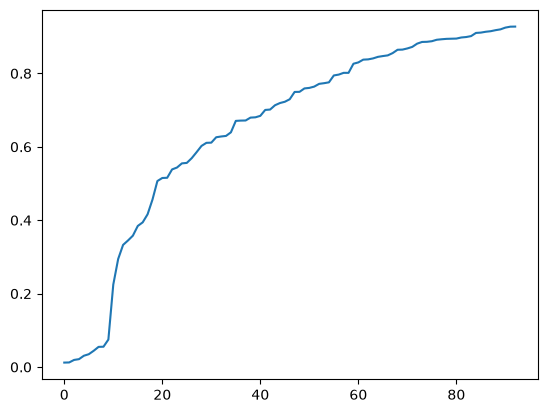

In [50]:
plt.plot(np.sort(r2))
np.argsort(r2)


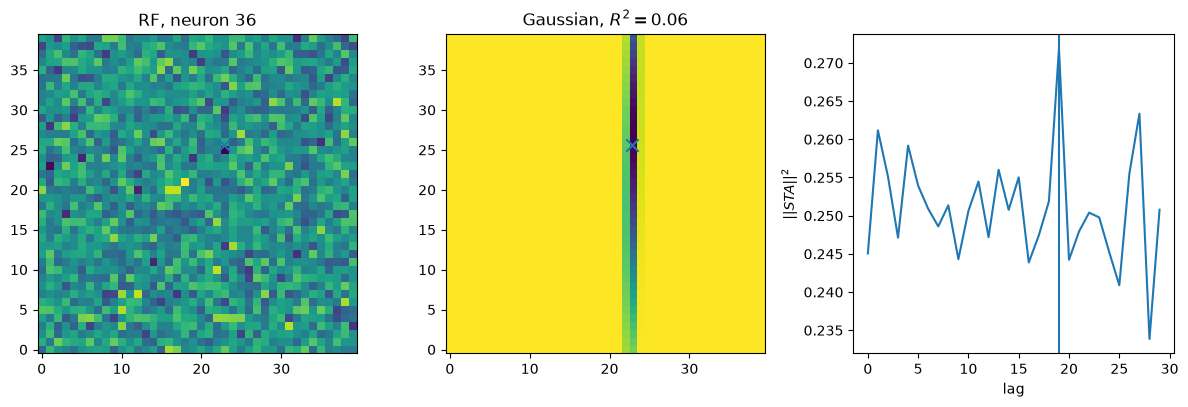

In [48]:
plot_rf_fit(fits[36])

In [26]:
from scipy.spatial.distance import cdist

D_rf = cdist(
    centers,
    centers,
)

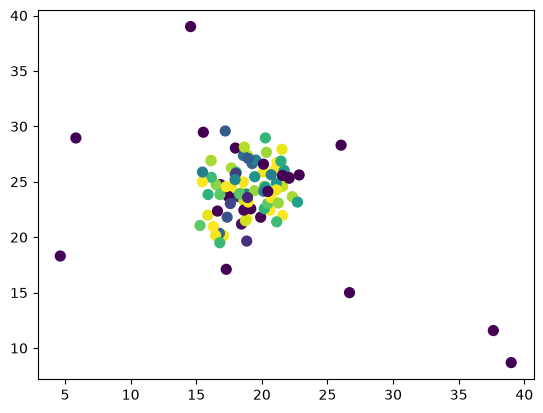

In [33]:
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c=r2,
    cmap="viridis",
    s=50,
    vmin=0.5,
    vmax=0.9
)

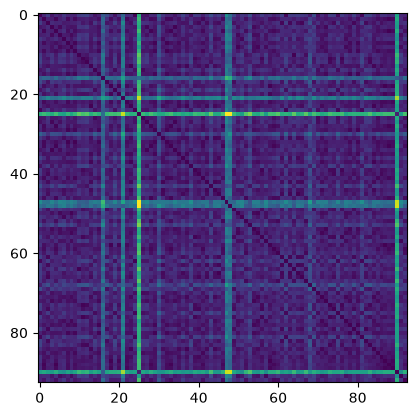

In [34]:
plt.imshow(D_rf)

### Learning

In [2]:
class WindowedAttention(nn.Module):
    def __init__(self, n_neurons, d_model, window_size):
        super().__init__()

        self.d_model = d_model
        self.window_size = window_size

        self.W_Q = nn.Linear(n_neurons, d_model, bias=False)
        self.W_K = nn.Linear(n_neurons, d_model, bias=False)
        self.W_V = nn.Linear(n_neurons, d_model, bias=False)

        self.lag_bias = nn.Parameter(torch.zeros(window_size))

        self.W_O = nn.Linear(d_model, n_neurons)

    def forward(self, s):
        """
        s: (B, T, N)

        returns
        -------
        logits:    (B, T, N)
        attention: (B, T, L)

        attention[..., l] corresponds to lag l:
            l = 0 -> t
            l = 1 -> t-1
            ...
        """

        B, T, N = s.shape
        L = self.window_size

        q = self.W_Q(s)                       # (B,T,d)
        k = self.W_K(s)                       # (B,T,d)
        v = self.W_V(s)                       # (B,T,d)

        # Left pad time by L-1
        k_pad = F.pad(k, (0, 0, L - 1, 0)) # [0,...,0,x_0, ..., x_{t-1}] with the zeros L-1 times
        v_pad = F.pad(v, (0, 0, L - 1, 0))

        # Sliding windows.
        # unfold gives (B,T,d,L)
        # permute to (B,T,L,d)
        # results in:
        # [0*(L-1), x_0]
        # [0*(L-2), x_0, x_1]
        # [0*(L-3), x_0, x_1, x_2] etc
        k_lag = k_pad.unfold(1, L, 1).permute(0, 1, 3, 2)
        v_lag = v_pad.unfold(1, L, 1).permute(0, 1, 3, 2)

        # unfold orders oldest -> newest, so we flip to get newest -> oldest
        k_lag = k_lag.flip(2)
        v_lag = v_lag.flip(2)

        # q(t)^T k(t-l)
        scores = torch.einsum(
            "btd,btld->btl",
            q,
            k_lag,
        ) / self.d_model**0.5

        scores = scores + self.lag_bias[None, None, :]

        # valid[t,l] = l <= t
        t = torch.arange(T, device=s.device)[:, None]
        l = torch.arange(L, device=s.device)[None, :]

        mask = l <= t                         # (T,L)

        scores = scores.masked_fill(
            ~mask[None],
            -torch.inf,
        )

        attention = torch.softmax(scores, dim=-1)

        # z(t) = sum_l A_l(t) v(t-l)
        z = torch.einsum(
            "btl,btld->btd",
            attention,
            v_lag,
        )

        logits = self.W_O(z)

        return logits, attention

### Train

In [4]:
movie_index = 0

num_reps = int(nreps[movie_index])

spikes = torch.as_tensor(
    binned_spikes[:num_reps, :, :, movie_index],
    dtype=torch.float32,
)  # (reps, time, neurons)

mean_spikes = spikes.mean(dim=0)  # (time, neurons)

window_size = 50
slice_length = 250
num_slices_per_rep = 100
num_epochs = 5

model = WindowedAttention(
    n_neurons=ncell,
    d_model=128,
    window_size=window_size,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

loss_fn = nn.BCEWithLogitsLoss()

model.train()

pbar = tqdm(range(num_epochs), desc="Epochs")

for epoch in pbar:

    for rep in range(num_reps):

        spikes_rep = spikes[rep]

        for slice_idx in range(num_slices_per_rep):

            # Need one additional bin because target is shifted by +1.
            start_idx = torch.randint(
                0,
                spikes_rep.shape[0] - slice_length,
                (1,),
            ).item()

            # Current repetition:
            # x[t] = spikes_rep[t]
            x = spikes_rep[
                start_idx : start_idx + slice_length
            ].unsqueeze(0)  # (1, T, N)

            # Mean movie response one step in the future:
            # target[t] = mean_spikes[t+1]
            target = mean_spikes[
                start_idx + 1 : start_idx + slice_length + 1
            ].unsqueeze(0)  # (1, T, N)

            x = x.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            logits, attention = model(x)

            loss = loss_fn(logits, target)

            loss.backward()
            optimizer.step()

            pbar.set_postfix({ "rep": rep, "slice": slice_idx, "loss": loss.item()})

Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

||M||:       17.1510
||M_sym||:   11.7715
||M_asym||:  12.4736
asym / sym:  1.0596
asym / total: 0.7273
asym power fraction: 0.5289


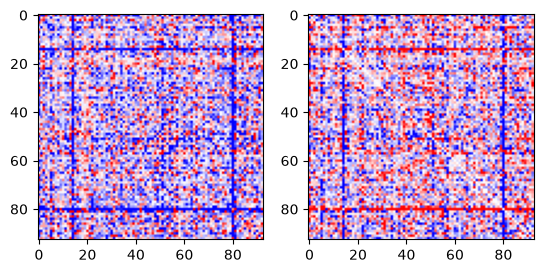

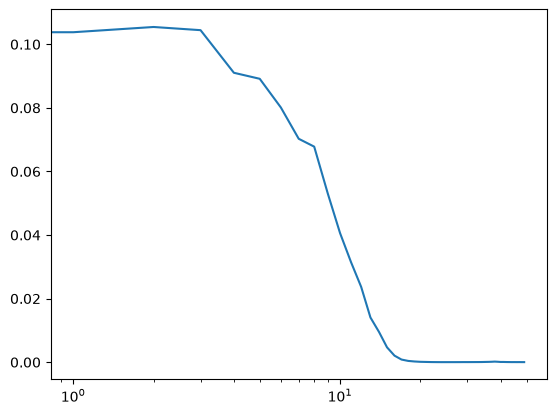

In [11]:
with torch.no_grad():
    model.eval()

    time_bias = model.lag_bias.detach().cpu()
    W_K = model.W_K.weight.detach().cpu()
    W_Q = model.W_Q.weight.detach().cpu()
    W_V = model.W_V.weight.detach().cpu()
    W_O = model.W_O.weight.detach().cpu()
    M = W_Q.T @ W_K / model.d_model**0.5
    M_sym = 0.5 * (M + M.T)
    M_asym = 0.5 * (M - M.T)
    M_norm = torch.linalg.norm(M, ord="fro")
    M_sym_norm = torch.linalg.norm(M_sym, ord="fro")
    M_asym_norm = torch.linalg.norm(M_asym, ord="fro")
    asym_power_fraction = (M_asym_norm / M_norm)**2
    print(f"||M||:       {M_norm:.4f}")
    print(f"||M_sym||:   {M_sym_norm:.4f}")
    print(f"||M_asym||:  {M_asym_norm:.4f}")

    print(f"asym / sym:  {(M_asym_norm / M_sym_norm).item():.4f}")
    print(f"asym / total: {(M_asym_norm / M_norm).item():.4f}")
    print(f"asym power fraction: {asym_power_fraction.item():.4f}")

    M_sym_eigvals, M_sym_eigvecs = torch.linalg.eigh(M_sym)

    fig, axs = plt.subplots(ncols=2)
    axs[0].imshow(M_sym, cmap="bwr", vmin=-0.1, vmax=0.1)
    axs[1].imshow(M_asym, cmap="bwr", vmin=-0.1, vmax=0.1)
    plt.show()
    plt.plot(torch.softmax(time_bias, dim=0).numpy())
    plt.xscale("log")
    plt.show()

In [ ]:
def sta_neuron(stim, spikes, neuron, max_lag=30):

    T = min(stim.shape[2], spikes.shape[1])

    stim = stim[:, :, :T]
    s = spikes[neuron, :T]

    spike_times = np.flatnonzero(s > 0)

    stim_mean = stim.mean(axis=2)

    sta = np.zeros((max_lag, stim.shape[0], stim.shape[1]))

    for lag in range(max_lag):
        valid = spike_times[spike_times >= lag]

        sta[lag] = (
            stim[:, :, valid - lag].mean(axis=2)
            - stim_mean
        )

    return sta

In [ ]:
sta_all = []
for neuron in tqdm(range(ncell)):
    sta = sta_neuron(stimulusFrames, binaryCheckerboard, neuron, max_lag=30)
    sta_all.append(sta)
sta_all = np.array(sta_all)